# Does beta drift weaken eddy relative vorticity?

This notebook tests whether relative-vorticity magnitude decreases while AEs drift equatorward and CEs drift poleward. With the dataset convention `w > 0` for AEs and `w < 0` for CEs, both polarities should have $d|w|/dt<0$ during beta-aligned drift.

The primary population is composed of contiguous off-shelf, planetary-PV-gradient-dominant trajectory segments. Track velocity and vorticity tendency are calculated from complete trajectories **before** filtering. Daily-tendency results are supplemented by the less noisy cumulative prediction $\Delta w \simeq -\Delta f$.

In [1]:
# Analysis settings
REGION_MODE = 'off_shelf'       # 'off_shelf', 'on_shelf', or 'all'
MIN_PLAN_TOPO_RATIO = 1.0       # set to None for no PV-dominance filter
DRIFT_METHODS = ['clim_surface', 'clim_500', 'clim_200']
PRIMARY_METHOD = 'clim_200' #'ann_200'
SMOOTH_WINDOW = 5
MAX_SEGMENT_GAP_DAYS = 2
MIN_SEGMENT_OBSERVATIONS = 5
N_BOOT = 5000
SEED = 42

In [2]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path.cwd()
if not (HERE / 'background_flow_tools.py').exists():
    HERE = Path('MRes/seacofs_eddy_tilt_analysis/beta_effect_background_flow').resolve()
sys.path.insert(0, str(HERE))
sys.path.insert(0, str(HERE.parent))

import seacofs_tilt_tools as tilt
from background_flow_tools import BackgroundConfig, load_background_cache
from analysis_tools import METHODS, add_track_velocity, add_residual_velocities
plt.style.use('seaborn-v0_8-whitegrid')

## 1. Load complete trajectories before selecting the physical regime

This order matters. Differentiating a trajectory after removing non-qualifying days can create gaps and discard eddies with too few retained observations.

In [3]:
paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
eddies, _ = tilt.load_tilt_tables(paths, add_regions=True, grid=grid)
eddies = tilt.add_pv_gradient_terms(eddies, grid)
background = load_background_cache(BackgroundConfig())

full = eddies.merge(background, on=['Eddy', 'Day'], how='inner', validate='one_to_one')
full = add_track_velocity(full, grid.angle, window=SMOOTH_WINDOW)
full = add_residual_velocities(full)
full = full.sort_values(['Eddy', 'Day']).copy()
full['abs_w'] = full['w'].abs()
full['expected_sign'] = np.where(full['Cyc'].eq('AE'), 1.0, -1.0)
print(f"Complete cache: {len(full):,} observations, {full['Eddy'].nunique():,} eddies")

Complete cache: 127,426 observations, 2,982 eddies


## 2. Smoothed observed tendencies

`dabsw_dt` is the observed tendency of relative-vorticity magnitude. Negative values indicate weakening for both polarities. A centred rolling median reduces one-day noise before taking a time-aware derivative.

In [4]:
def add_smoothed_gradient(frame, source, output, window=5):
    frame[output] = np.nan
    for indices in frame.groupby('Eddy', sort=False).groups.values():
        part = frame.loc[indices].sort_values('Day')
        values = part[source].to_numpy(float)
        days = part['Day'].to_numpy(float)
        valid = np.isfinite(values) & np.isfinite(days)
        gradient = np.full(len(part), np.nan)
        if valid.sum() >= 3 and np.unique(days[valid]).size >= 3:
            gradient[valid] = np.gradient(values[valid], days[valid] * 86400.0)
        gradient = pd.Series(gradient, index=part.index).rolling(
            window, center=True, min_periods=3).median()
        frame.loc[part.index, output] = gradient
    return frame

full = add_smoothed_gradient(full, 'w', 'dw_dt_s2', SMOOTH_WINDOW)
full = add_smoothed_gradient(full, 'abs_w', 'dabsw_dt_s2', SMOOTH_WINDOW)

## 3. Select contiguous off-shelf, planetary-dominant segments

Off shelf, the shallow-water stretching term is less likely to dominate. Contiguous segments prevent cumulative changes from crossing excluded shelf or topographic-dominant intervals.

In [5]:
if REGION_MODE == 'off_shelf':
    region_mask = full['Region'].isin(['U1', 'U2', 'D1', 'D2'])
elif REGION_MODE == 'on_shelf':
    region_mask = full['Region'].isin(['S1', 'S2'])
elif REGION_MODE == 'all':
    region_mask = pd.Series(True, index=full.index)
else:
    raise ValueError("REGION_MODE must be 'off_shelf', 'on_shelf', or 'all'.")

if MIN_PLAN_TOPO_RATIO is None:
    pv_mask = pd.Series(True, index=full.index)
else:
    pv_mask = full['topo_plan_ratio'] < -np.log(MIN_PLAN_TOPO_RATIO)

selected = full.loc[region_mask & pv_mask].sort_values(['Eddy', 'Day']).copy()
new_segment = (
    selected['Eddy'].ne(selected['Eddy'].shift())
    | selected.groupby('Eddy')['Day'].diff().gt(MAX_SEGMENT_GAP_DAYS)
)
selected['segment_number'] = new_segment.groupby(selected['Eddy']).cumsum().astype(int)
selected['segment_id'] = selected['Eddy'].astype(str) + '_' + selected['segment_number'].astype(str)
segment_n = selected.groupby('segment_id')['Day'].transform('size')
selected = selected.loc[segment_n >= MIN_SEGMENT_OBSERVATIONS].copy()
print(f"Selected {len(selected):,} observations, {selected['Eddy'].nunique():,} eddies, "
      f"{selected['segment_id'].nunique():,} contiguous segments")
display(pd.crosstab(selected['Cyc'], columns='observations').join(
    selected.groupby('Cyc')['Eddy'].nunique().rename('eddies')))

Selected 8,220 observations, 446 eddies, 746 contiguous segments


,observations,eddies
Cyc,,
AE,7471,348
CE,749,98


## 4. Does stronger beta-aligned drift accompany faster weakening?

Positive aligned velocity means northward/equatorward for AEs and southward/poleward for CEs. For each method, the predicted magnitude tendency is $\operatorname{sign}(w)(-\beta v_r)$. The plots use one median point per eddy so long-lived eddies do not dominate.

,method,Cyc,eddies,spearman,ci_low,ci_high
0,clim_surface,AE,348,-0.020890,-0.132778,0.092285
1,clim_surface,CE,98,-0.053077,-0.258702,0.157721
2,clim_500,AE,348,-0.005425,-0.119955,0.107711
3,clim_500,CE,98,-0.082850,-0.289073,0.128148
4,clim_200,AE,348,-0.012382,-0.126433,0.099527
5,clim_200,CE,98,-0.085439,-0.287352,0.126295


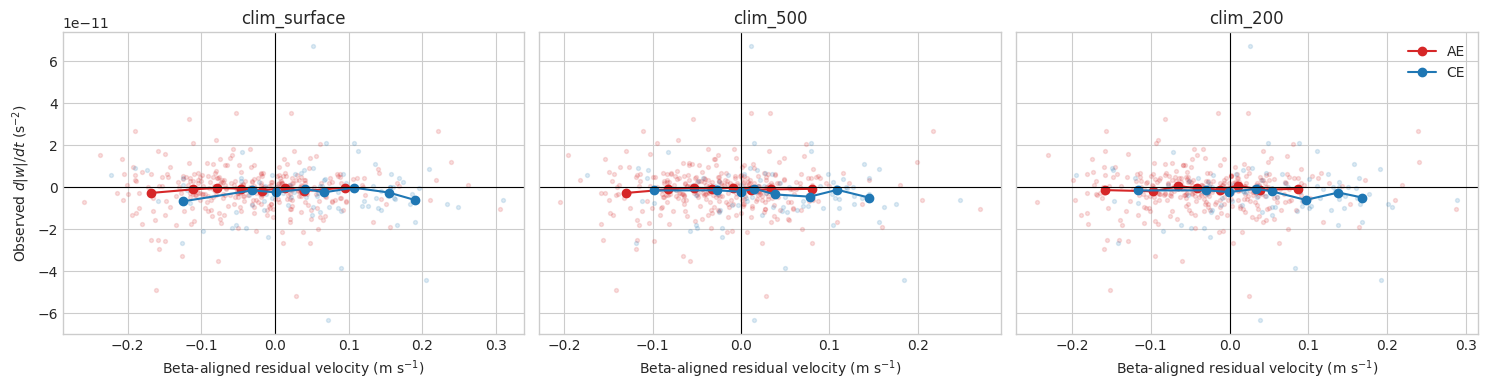

In [6]:
def bootstrap_corr(frame, x, y, n_boot=N_BOOT, seed=SEED):
    pairs = frame[['Eddy', x, y]].dropna().groupby('Eddy')[[x, y]].median()
    if len(pairs) < 3:
        return np.nan, np.nan, np.nan, len(pairs)
    estimate = pairs[x].corr(pairs[y], method='spearman')
    rng = np.random.default_rng(seed)
    values = pairs.to_numpy()
    boot = np.empty(n_boot)
    for i in range(n_boot):
        sample = values[rng.integers(0, len(values), len(values))]
        boot[i] = pd.Series(sample[:, 0]).corr(pd.Series(sample[:, 1]), method='spearman')
    return estimate, *np.nanpercentile(boot, [2.5, 97.5]), len(pairs)

fig, axes = plt.subplots(1, len(DRIFT_METHODS), figsize=(5*len(DRIFT_METHODS), 4), sharey=True)
if len(DRIFT_METHODS) == 1:
    axes = [axes]
daily_results = []
for ax, method in zip(axes, DRIFT_METHODS):
    v = f'{method}_residual_north_ms'
    aligned = f'{method}_beta_aligned_v_ms'
    predicted = f'{method}_predicted_dabsw_dt_s2'
    selected[aligned] = selected['expected_sign'] * selected[v]
    selected[predicted] = np.sign(selected['w']) * (-selected['beta'] * selected[v])
    eddy_values = selected.groupby(['Eddy', 'Cyc'])[[aligned, 'dabsw_dt_s2']].median().reset_index()
    for cyc, colour in [('AE', 'tab:red'), ('CE', 'tab:blue')]:
        part = eddy_values[eddy_values['Cyc'].eq(cyc)].dropna()
        ax.scatter(part[aligned], part['dabsw_dt_s2'], s=8, alpha=.15, color=colour)
        if len(part) >= 20:
            part = part.copy()
            part['bin'] = pd.qcut(part[aligned], 8, duplicates='drop')
            curve = part.groupby('bin', observed=True)[[aligned, 'dabsw_dt_s2']].median()
            ax.plot(curve[aligned], curve['dabsw_dt_s2'], 'o-', color=colour, label=cyc)
        est, low, high, n = bootstrap_corr(selected[selected['Cyc'].eq(cyc)], aligned, 'dabsw_dt_s2')
        daily_results.append({'method': method, 'Cyc': cyc, 'eddies': n,
                              'spearman': est, 'ci_low': low, 'ci_high': high})
    ax.axhline(0, color='k', lw=.8); ax.axvline(0, color='k', lw=.8)
    ax.set(title=method, xlabel='Beta-aligned residual velocity (m s$^{-1}$)')
axes[0].set_ylabel(r'Observed $d|w|/dt$ (s$^{-2}$)')
axes[-1].legend(); plt.tight_layout()
display(pd.DataFrame(daily_results))

## 5. Direct daily budget: predicted versus observed magnitude tendency

A 1:1 line and identical axes expose both sign and scale agreement. Because daily derivatives are noisy, binned medians are shown over the density cloud.

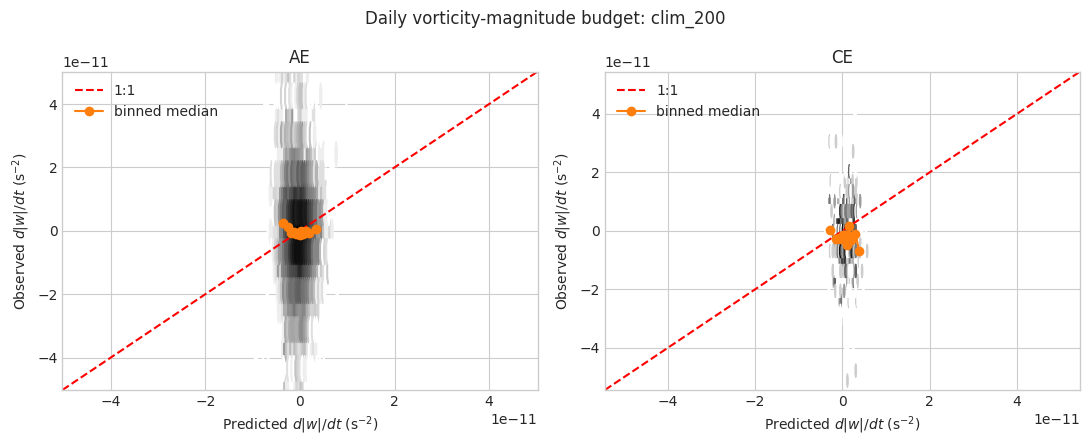

In [7]:
method = PRIMARY_METHOD
xcol = f'{method}_predicted_dabsw_dt_s2'
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (cyc, part) in zip(axes, selected.groupby('Cyc')):
    use = part[[xcol, 'dabsw_dt_s2']].replace([np.inf, -np.inf], np.nan).dropna()
    ax.hexbin(use[xcol], use['dabsw_dt_s2'], gridsize=45, mincnt=1, bins='log', cmap='Greys')
    limit = np.nanpercentile(np.abs(use.to_numpy()), 99)
    ax.plot([-limit, limit], [-limit, limit], 'r--', label='1:1')
    use = use.copy(); use['bin'] = pd.qcut(use[xcol], 12, duplicates='drop')
    curve = use.groupby('bin', observed=True).median()
    ax.plot(curve[xcol], curve['dabsw_dt_s2'], 'o-', color='tab:orange', label='binned median')
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit), title=cyc,
           xlabel=r'Predicted $d|w|/dt$ (s$^{-2}$)', ylabel=r'Observed $d|w|/dt$ (s$^{-2}$)')
    ax.legend()
fig.suptitle(f'Daily vorticity-magnitude budget: {method}')
plt.tight_layout()

## 6. Cumulative test: $\Delta w$ versus $-\Delta f$

For each contiguous segment, conservation of absolute vorticity without stretching predicts $w-w_0\simeq-(f-f_0)$. Segment endpoints provide one cumulative response per event and avoid treating every day as independent.

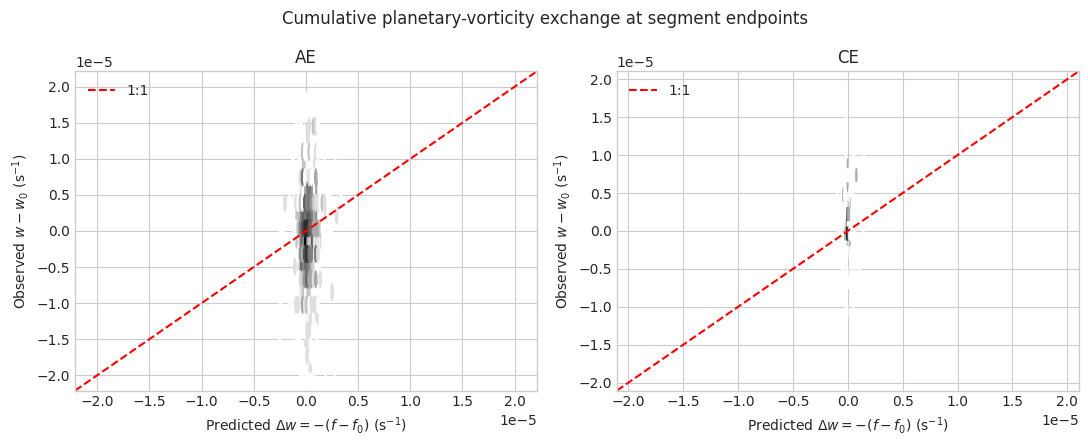

In [8]:
def add_segment_changes(frame, method):
    out = frame.sort_values(['segment_id', 'Day']).copy()
    grouped = out.groupby('segment_id', sort=False)
    out['delta_w'] = out['w'] - grouped['w'].transform('first')
    out['delta_abs_w'] = out['abs_w'] - grouped['abs_w'].transform('first')
    out['predicted_delta_w'] = -(out['f'] - grouped['f'].transform('first'))
    dt = grouped['Day'].diff() * 86400.0
    v = out[f'{method}_residual_north_ms']
    previous_v = grouped[f'{method}_residual_north_ms'].shift()
    step_m = 0.5 * (v + previous_v) * dt
    out['cumulative_north_m'] = step_m.fillna(0).groupby(out['segment_id']).cumsum()
    out['aligned_displacement_km'] = out['expected_sign'] * out['cumulative_north_m'] / 1000.0
    out['segment_fraction'] = grouped.cumcount() / (grouped['Day'].transform('size') - 1)
    out['abs_w_normalised'] = out['abs_w'] / grouped['abs_w'].transform('first')
    return out

cumulative = add_segment_changes(selected, PRIMARY_METHOD)
terminal = cumulative.groupby('segment_id', sort=False).tail(1).copy()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (cyc, part) in zip(axes, terminal.groupby('Cyc')):
    use = part[['predicted_delta_w', 'delta_w']].dropna()
    ax.hexbin(use['predicted_delta_w'], use['delta_w'], gridsize=35, mincnt=1, bins='log', cmap='Greys')
    limit = np.nanpercentile(np.abs(use.to_numpy()), 99)
    ax.plot([-limit, limit], [-limit, limit], 'r--', label='1:1')
    ax.set(xlim=(-limit, limit), ylim=(-limit, limit), title=cyc,
           xlabel=r'Predicted $\Delta w=-(f-f_0)$ (s$^{-1}$)',
           ylabel=r'Observed $w-w_0$ (s$^{-1}$)')
    ax.legend()
fig.suptitle('Cumulative planetary-vorticity exchange at segment endpoints')
plt.tight_layout()

## 7. Does cumulative beta-aligned displacement reduce $|w|$?

This is the most intuitive weakening plot. The beta-effect hypothesis predicts a negative relationship in both AE and CE panels.

,Cyc,segments/eddies,spearman,ci_low,ci_high
0,AE,348,-0.096224,-0.202751,0.014993
1,CE,98,0.116233,-0.097557,0.328322


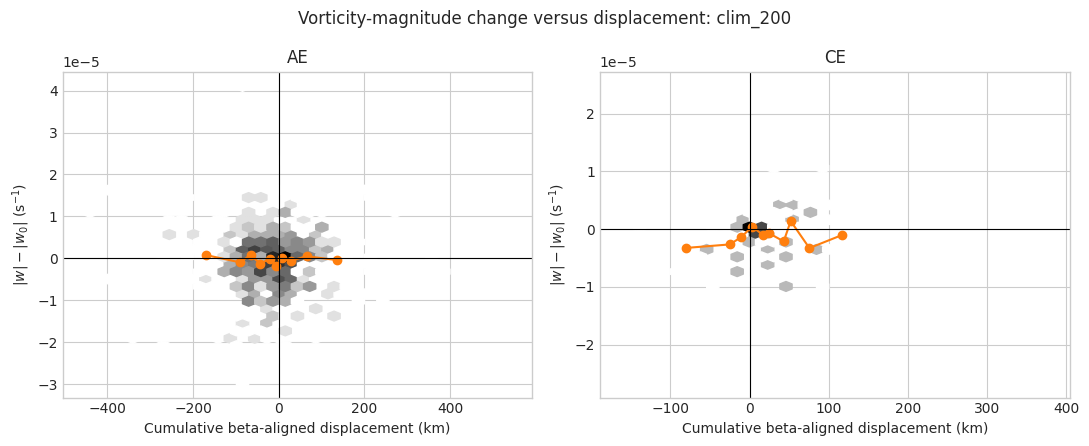

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, (cyc, part) in zip(axes, terminal.groupby('Cyc')):
    use = part[['aligned_displacement_km', 'delta_abs_w']].dropna().copy()
    ax.hexbin(use['aligned_displacement_km'], use['delta_abs_w'], gridsize=35, mincnt=1, bins='log', cmap='Greys')
    if len(use) >= 20:
        use['bin'] = pd.qcut(use['aligned_displacement_km'], 10, duplicates='drop')
        curve = use.groupby('bin', observed=True).median()
        ax.plot(curve['aligned_displacement_km'], curve['delta_abs_w'], 'o-', color='tab:orange')
    ax.axhline(0, color='k', lw=.8); ax.axvline(0, color='k', lw=.8)
    ax.set(title=cyc, xlabel='Cumulative beta-aligned displacement (km)',
           ylabel=r'$|w|-|w_0|$ (s$^{-1}$)')
fig.suptitle(f'Vorticity-magnitude change versus displacement: {PRIMARY_METHOD}')
plt.tight_layout()

endpoint_results = []
for cyc in ['AE', 'CE']:
    est, low, high, n = bootstrap_corr(terminal[terminal['Cyc'].eq(cyc)],
                                        'aligned_displacement_km', 'delta_abs_w')
    endpoint_results.append({'Cyc': cyc, 'segments/eddies': n, 'spearman': est,
                             'ci_low': low, 'ci_high': high})
display(pd.DataFrame(endpoint_results))

## 8. Composite vorticity evolution along qualifying segments

Segments are classified by whether their median residual propagation is beta aligned. Faster decay of normalised $|w|$ in the aligned group would support beta-related weakening. Curves are descriptive; eddy-bootstrap endpoint results above provide the primary inference.

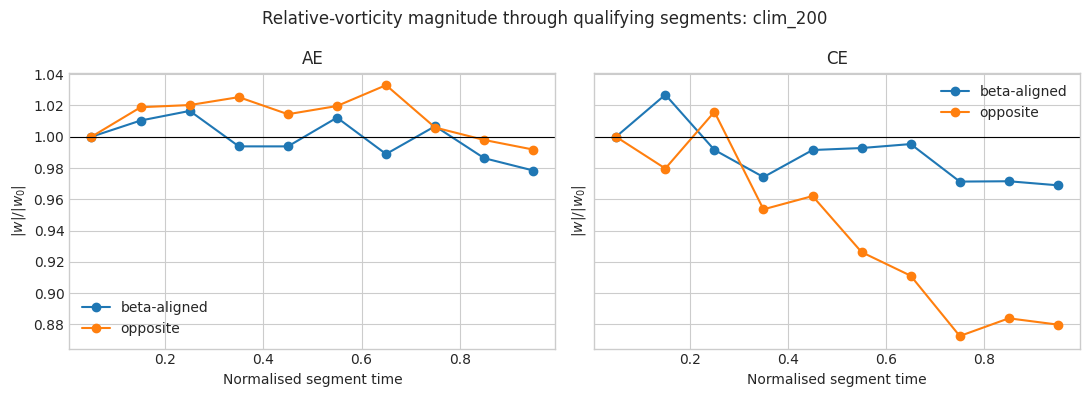

In [10]:
aligned_col = f'{PRIMARY_METHOD}_beta_aligned_v_ms'
segment_alignment = cumulative.groupby('segment_id')[aligned_col].median().gt(0)
cumulative['drift_group'] = cumulative['segment_id'].map(
    segment_alignment.map({True: 'beta-aligned', False: 'opposite'}))
cumulative['life_bin'] = pd.cut(cumulative['segment_fraction'], np.linspace(0, 1, 11), include_lowest=True)
composite = (cumulative.groupby(['Cyc', 'drift_group', 'life_bin'], observed=True)
             .agg(abs_w_normalised=('abs_w_normalised', 'median'),
                  eddies=('Eddy', 'nunique')).reset_index())
composite['segment_fraction'] = composite['life_bin'].apply(lambda value: value.mid).astype(float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (cyc, part) in zip(axes, composite.groupby('Cyc')):
    for group, curve in part.groupby('drift_group'):
        ax.plot(curve['segment_fraction'], curve['abs_w_normalised'], 'o-', label=group)
    ax.axhline(1, color='k', lw=.8)
    ax.set(title=cyc, xlabel='Normalised segment time', ylabel=r'$|w|/|w_0|$')
    ax.legend()
fig.suptitle(f'Relative-vorticity magnitude through qualifying segments: {PRIMARY_METHOD}')
plt.tight_layout()

## Interpretation

Evidence for beta-driven vorticity loss requires several results to agree: (1) more-positive beta-aligned drift accompanies more-negative $d|w|/dt$; (2) predicted and observed daily magnitude tendencies share sign and scale; (3) cumulative $w-w_0$ follows $-(f-f_0)$; (4) cumulative beta-aligned displacement accompanies loss of $|w|$ for both polarities; and (5) beta-aligned segments weaken faster than opposite-drift segments.

A flat daily budget but coherent cumulative relationship would indicate that daily noise obscures a weak beta signal. Failure of the cumulative diagnostics means the available vorticity changes are not explained by planetary-vorticity exchange alone. On-shelf analysis should additionally examine $q=(f+w)/h$, because changing water-column thickness introduces vortex stretching.